# Human in the loop

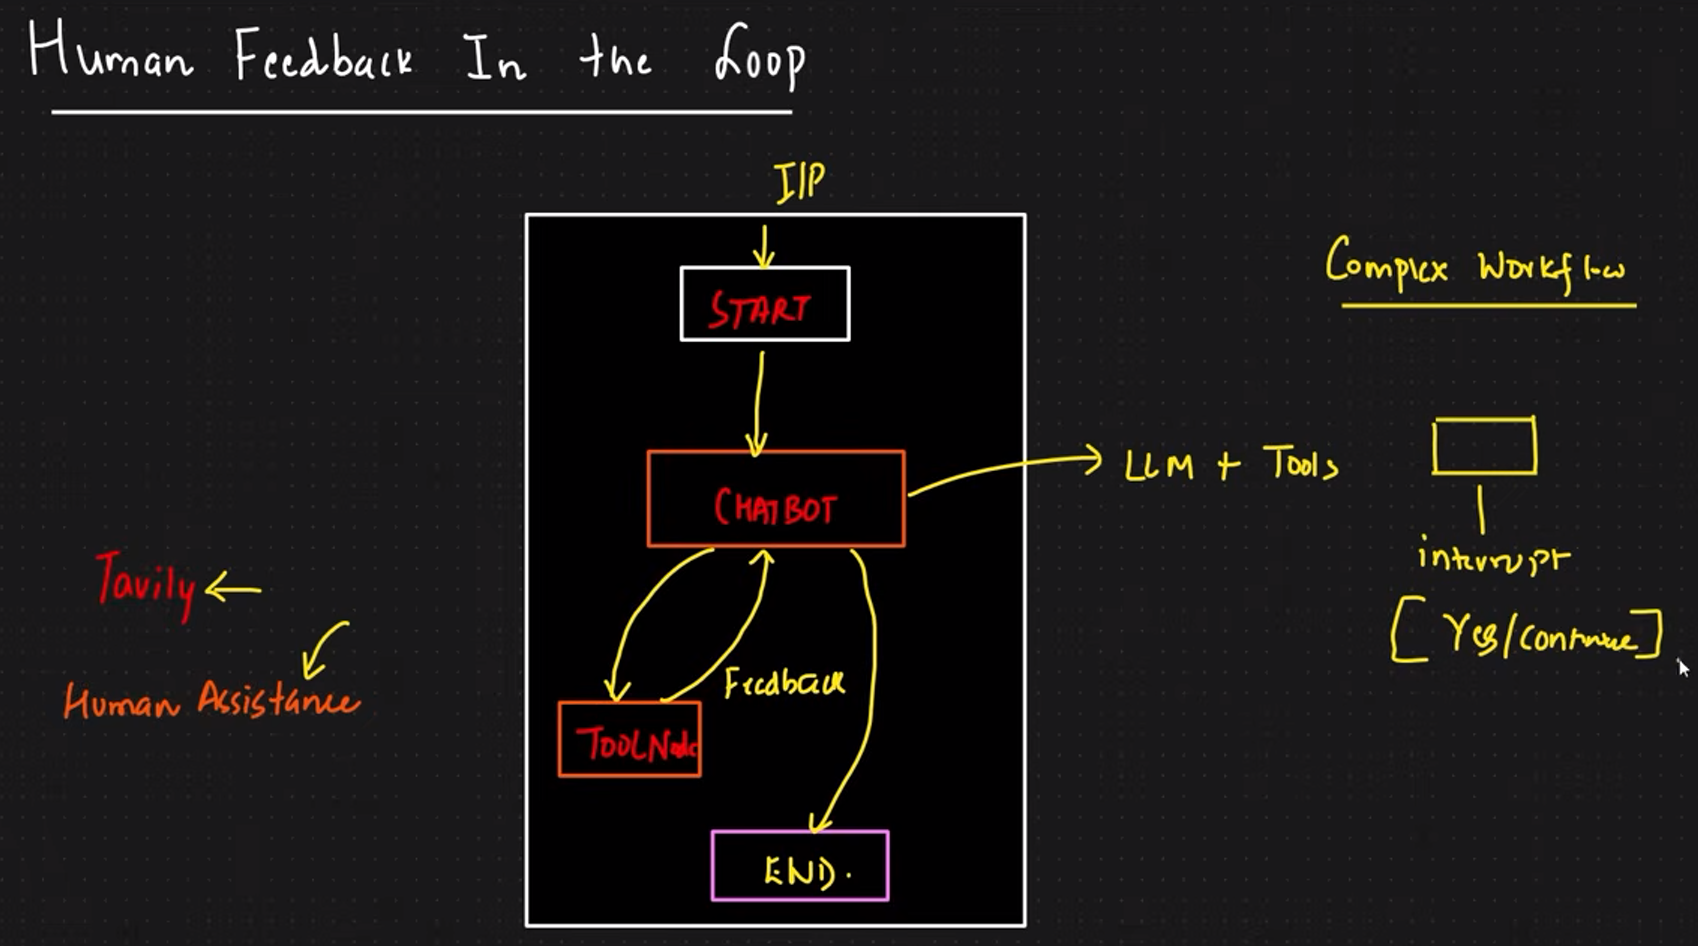

In [1]:
import os
from langchain.chat_models import init_chat_model
llm=init_chat_model('groq:llama-3.1-8b-instant')
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000217B94051C0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000217B9407E90>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [2]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool
def human_assistance(query:str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]
    
tool=TavilySearch(max_results=2)
tools=[tool,human_assistance]
llm_wihth_tools=llm.bind_tools(tools)

def chatbot(state:State):
    message=llm_wihth_tools.invoke(state["messages"])
    # because we will be interupting tool during tool execution,
    # we disable parallel tool calling to avoid repeating any tool invocation when we resume

    return {"messages":[message]}

graph_builder.add_node("chatbot", chatbot)

tool_node=ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")


In [3]:
memory=MemorySaver()
graph=graph_builder.compile(checkpointer=memory)


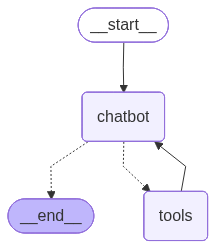

In [4]:
from IPython.display import display, Image
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception :
    # this requires some extra dependencies and is optional
    pass

In [6]:
user_input = "I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (xw1x8bfnb)
 Call ID: xw1x8bfnb
  Args:
    query: I need expert guidance and assistance for building an AI agent, can you assign a human expert to assist me with this project? I need help with the architecture, development, and training of the AI agent.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (xw1x8bfnb)
 Call ID: xw1x8bfnb
  Args:
    query: I need expert guidance and assistance for building an AI agent, can you assign a human expert to assist me with this project? I need help with the architecture, development, and training of the AI agent.


In [7]:
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (xw1x8bfnb)
 Call ID: xw1x8bfnb
  Args:
    query: I need expert guidance and assistance for building an AI agent, can you assign a human expert to assist me with this project? I need help with the architecture, development, and training of the AI agent.
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (x0a28meb2)
 Call ID: x0a28meb2
  Args:
    query: LangGraph AI agent architecture development training
    search_depth: advanced
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"q